In [1706]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

In [1707]:
df = pd.read_csv("Hospital_Data.csv")

In [1708]:
print(df.head())

  Hospital_Type    SIR
0         Acute  0.919
1         Acute  0.512
2         Acute  0.677
3         Acute  0.667
4         Acute  0.751


In [1709]:
df.shape
df.describe()

,SIR
count,74.000000
mean,0.799230
std,0.335139
min,0.347000
25%,0.625500
50%,0.730500
75%,0.830250
max,2.287000


<Axes: xlabel='Hospital_Type', ylabel='SIR'>

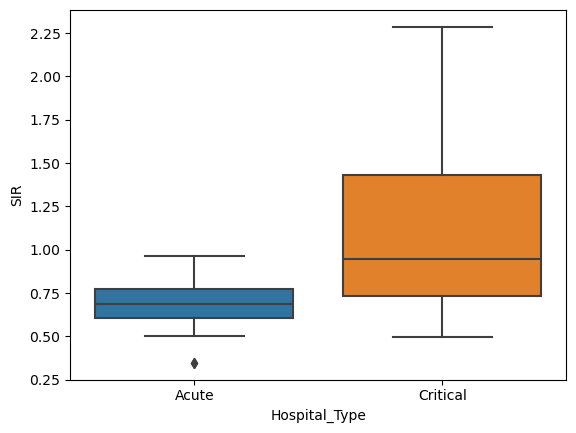

In [1710]:
sns.boxplot(y='SIR',x='Hospital_Type',data=df)

In [1711]:
X = df[['Hospital_Type']]
X = pd.get_dummies(data=X, drop_first=True, dtype=int)
X.head()

,Hospital_Type_Critical
0,0
1,0
2,0
3,0
4,0


In [1712]:
df['Log_SIR'] = np.log(df['SIR'])
print("Dataset with Log Transformed SIR:")
print(df.head())

Dataset with Log Transformed SIR:
  Hospital_Type    SIR   Log_SIR
0         Acute  0.919 -0.084469
1         Acute  0.512 -0.669431
2         Acute  0.677 -0.390084
3         Acute  0.667 -0.404965
4         Acute  0.751 -0.286350


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Density')

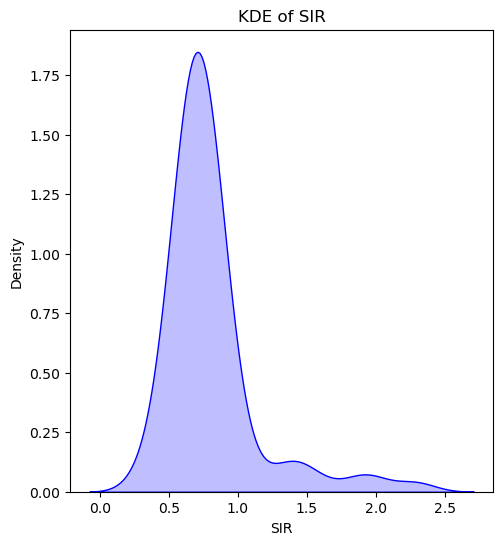

In [1713]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(df['SIR'], fill=True, color='blue')
plt.title('KDE of SIR')
plt.xlabel('SIR')
plt.ylabel('Density')

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


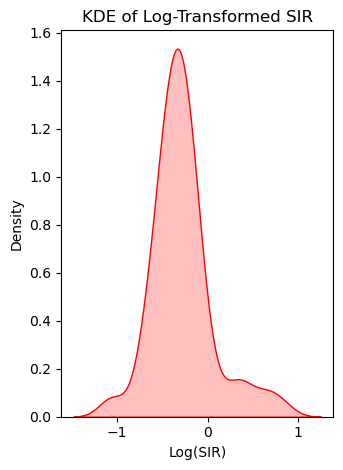

In [1714]:
plt.subplot(1, 2, 2)
sns.kdeplot(df['Log_SIR'], fill=True, color='red')
plt.title('KDE of Log-Transformed SIR')
plt.ylabel('Density')
plt.xlabel('Log(SIR)')
plt.tight_layout()
plt.show()

In [1715]:
Y = df['SIR']

In [1716]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(59, 1)
(15, 1)
(59,)
(15,)


In [1717]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [1718]:
print(model.intercept_)

0.6933111111111111


In [1719]:
coeff_parameter = pd.DataFrame(model.coef_,X.columns,columns=['Coefficient'])
coeff_parameter

,Coefficient
Hospital_Type_Critical,0.516832


In [1720]:
predictions = model.predict(X_test)
predictions

array([0.69331111, 1.21014286, 0.69331111, 0.69331111, 0.69331111,
       1.21014286, 0.69331111, 0.69331111, 0.69331111, 0.69331111,
       1.21014286, 0.69331111, 0.69331111, 0.69331111, 0.69331111])

<Axes: xlabel='SIR'>

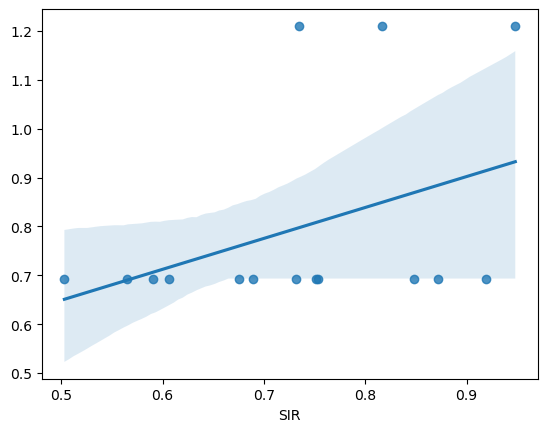

In [1721]:
sns.regplot(x=y_test, y=predictions)

In [1722]:
X_train_Sm= sm.add_constant(X_train)
X_train_Sm= sm.add_constant(X_train)
ls=sm.OLS(y_train,X_train_Sm.astype(float)).fit()
print(ls.summary())

                            OLS Regression Results                            
Dep. Variable:                    SIR   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     32.38
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           4.60e-07
Time:                        22:44:58   Log-Likelihood:                -11.036
No. Observations:                  59   AIC:                             26.07
Df Residuals:                      57   BIC:                             30.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [1723]:
categorical_features = ['Hospital_Type']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)
print(df.head())

     SIR   Log_SIR  Hospital_Type_Critical
0  0.919 -0.084469                   False
1  0.512 -0.669431                   False
2  0.677 -0.390084                   False
3  0.667 -0.404965                   False
4  0.751 -0.286350                   False


In [1724]:
df.corr()

,SIR,Log_SIR,Hospital_Type_Critical
SIR,1.000000,0.961667,0.564973
Log_SIR,0.961667,1.000000,0.526450
Hospital_Type_Critical,0.564973,0.526450,1.000000


<Axes: >

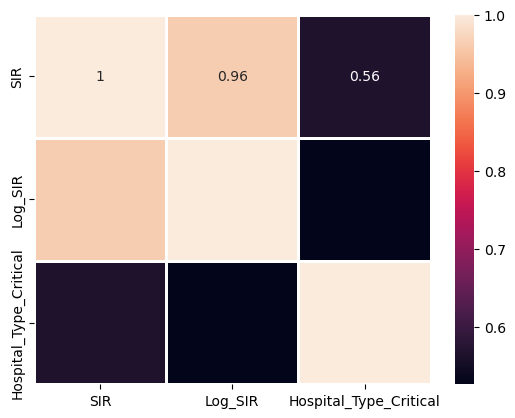

In [1725]:
sns.heatmap(df.corr(),annot=True,lw=1)

In [1726]:
Y = df['Log_SIR']

In [1727]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(59, 1)
(15, 1)
(59,)
(15,)


In [1728]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [1729]:
print(model.intercept_)

-0.38654576936182855


In [1730]:
coeff_parameter = pd.DataFrame(model.coef_,X.columns,columns=['Coefficient'])
coeff_parameter

,Coefficient
Hospital_Type_Critical,0.466114


In [1731]:
predictions = model.predict(X_test)
predictions

array([-0.38654577,  0.07956789, -0.38654577, -0.38654577, -0.38654577,
        0.07956789, -0.38654577, -0.38654577, -0.38654577, -0.38654577,
        0.07956789, -0.38654577, -0.38654577, -0.38654577, -0.38654577])

<Axes: xlabel='Log_SIR'>

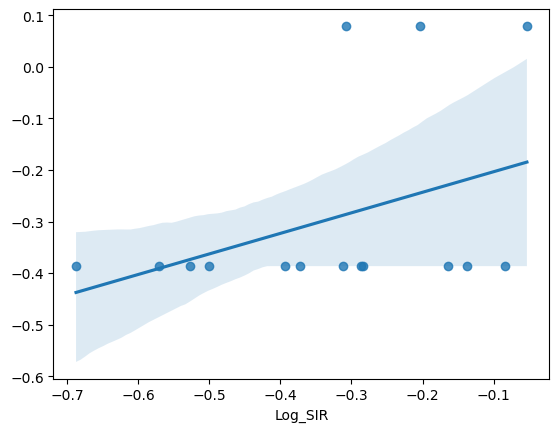

In [1732]:
sns.regplot(x=y_test, y=predictions)

In [1733]:
X_train_Sm= sm.add_constant(X_train)
X_train_Sm= sm.add_constant(X_train)
ls=sm.OLS(y_train,X_train_Sm.astype(float)).fit()
print(ls.summary())

                            OLS Regression Results                            
Dep. Variable:                Log_SIR   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     25.24
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           5.32e-06
Time:                        22:44:59   Log-Likelihood:                -12.284
No. Observations:                  59   AIC:                             28.57
Df Residuals:                      57   BIC:                             32.72
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0